Column1 A1g: 0.04 E2g: 0.03
Column2 A1g: 0.04 E2g: 0.01
Column3 A1g: 0.04 E2g: 0.00
Column4 A1g: 0.04 E2g: 0.00
Column5 A1g: 0.02 E2g: 0.02
Column6 A1g: 0.04 E2g: 0.00
Column7 A1g: 0.07 E2g: 0.00
Column8 A1g: 0.10 E2g: 0.00
Column9 A1g: 0.10 E2g: 0.00
Column10 A1g: 0.09 E2g: 0.00
Column11 A1g: 0.08 E2g: 0.01
Column12 A1g: 0.05 E2g: 0.00
Column13 A1g: 0.04 E2g: 0.03
Column14 A1g: 0.04 E2g: 0.01
Column15 A1g: 0.04 E2g: 0.00
Column16 A1g: 0.03 E2g: 0.00
Column17 A1g: 0.02 E2g: 0.02
Column18 A1g: 0.04 E2g: 0.00
Column19 A1g: 0.07 E2g: 0.00
Column20 A1g: 0.09 E2g: 0.00
Column21 A1g: 0.10 E2g: 0.00
Column22 A1g: 0.09 E2g: 0.00
Column23 A1g: 0.06 E2g: 0.00
Column24 A1g: 0.05 E2g: 0.00
Column25 A1g: 0.04 E2g: 0.03


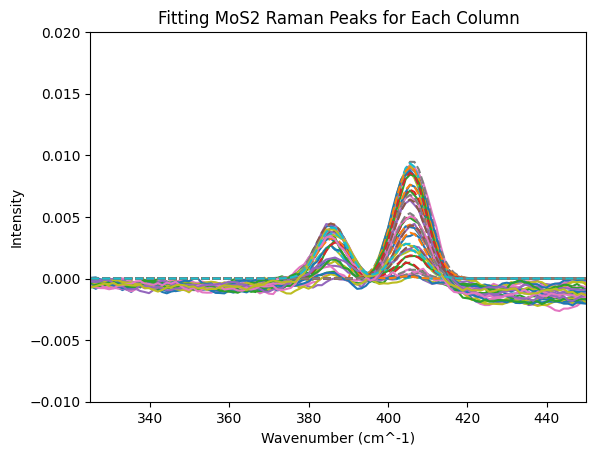

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

def double_gaussian(x, A1, mu1, sigma1, A2, mu2, sigma2):
    return gaussian(x, A1, mu1, sigma1) + gaussian(x, A2, mu2, sigma2)

def fit_peaks(x, y, initial_guess):
    bounds = ([0, -np.inf, 0, 0, -np.inf, 0], [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf])
    popt, pcov = curve_fit(double_gaussian, x, y, p0=initial_guess, bounds=bounds)
    return popt

def calculate_intensity(A, sigma):
    return A * sigma * np.sqrt(2 * np.pi)

def subtract_baseline(x, y, fitting_range):
    # Fit a straight line to the data within the fitting range to estimate the baseline
    mask = (x >= fitting_range[0]) & (x <= fitting_range[1])
    params = np.polyfit(x[mask], y[mask], 1)
    
    # Subtract the baseline from the original data
    y_baseline_subtracted = y - np.polyval(params, x)
    
    return y_baseline_subtracted

def normalize_data(data, reference_peak_range):
    num_columns = data.shape[1]

    # Find the index of the maximum within the reference peak range
    ref_peak_index = np.argmax(data[(data[:, 0] >= reference_peak_range[0]) & (data[:, 0] <= reference_peak_range[1]), 1])

    # Get the y-values of the reference peak
    ref_peak_values = data[(data[:, 0] >= reference_peak_range[0]) & (data[:, 0] <= reference_peak_range[1]), 1]

    # Normalize each column using the reference peak intensity
    for i in range(1, num_columns):
        y_data = data[:, i]
        y_data_normalized = y_data / ref_peak_values[ref_peak_index]
        data[:, i] = y_data_normalized

    return data

def fit_and_plot_each_column(data, initial_guess, fitting_range, y_range=None):
    num_columns = data.shape[1]

    for i in range(1, num_columns):  # Assuming the first column is the x-axis
        x_data = data[:, 0]
        y_data = data[:, i]

        # Subtract baseline
        y_data_baseline_subtracted = subtract_baseline(x_data, y_data, fitting_range)

        # Mask the data within the fitting range
        mask = (x_data >= fitting_range[0]) & (x_data <= fitting_range[1])
        x_data_fit = x_data[mask]
        y_data_fit = y_data_baseline_subtracted[mask]

        # Find the index of the maximum within a specific range
        range_for_max = fitting_range  # Use the specified fitting range
        max_index = np.argmax(y_data_fit[(x_data_fit >= range_for_max[0]) & (x_data_fit <= range_for_max[1])])

        # Use the index to get the corresponding x and y values for the maximum
        initial_guess = [y_data_fit[max_index], x_data_fit[max_index], 10, y_data_fit[max_index], x_data_fit[max_index] + 30, 10]

        # Fit the peaks using curve_fit
        params = fit_peaks(x_data_fit, y_data_fit, initial_guess)

        # Calculate peak intensities
        A1, mu1, sigma1, A2, mu2, sigma2 = params
        intensity_A1 = calculate_intensity(A1, sigma1)
        intensity_A2 = calculate_intensity(A2, sigma2)

        # Plot the original data, baseline-subtracted data, and the fitted peaks
        #plt.plot(x_data, y_data, label=f'Column {i} (Original)')
        plt.plot(x_data, y_data_baseline_subtracted, label=f'Column {i} (Baseline Subtracted)')
        plt.plot(x_data_fit, double_gaussian(x_data_fit, *params), label=f'Fitted Peaks (Column {i})', linestyle='--')

        # Display the calculated peak intensities for each column
        print(f'Column{i} A1g: {intensity_A1:.2f} E2g: {intensity_A2:.2f}')

    # Set the plot range and y-axis range
    plt.xlim(fitting_range)
    
    if y_range is None:
        plt.ylim(-0.01, 0.02)

    plt.title('Fitting MoS2 Raman Peaks for Each Column')
    plt.xlabel('Wavenumber (cm^-1)')
    plt.ylabel('Intensity')
    #plt.legend()
    plt.show()


def main():
    # Replace 'your_file.dat' with the actual file name
    file_path = 'C:/Users/rn487/OneDrive/Desktop/Importatnt Files/實驗室/Complex phonon mode/20240516_MoS2 QWP resolve Raman/RM15_box2_QWPout179_QWPin120_polar0-360Spectrum.dat'

    # Load data from the DAT file
    data = np.loadtxt(file_path)

    # Define initial guesses for the peaks (A1, mu1, sigma1, A2, mu2, sigma2)
    initial_guess = [max(data[:, 1]), data[np.argmax(data[:, 1]), 0], 10,
                     max(data[:, 1]), data[np.argmax(data[:, 1]), 0] + 30, 10]

    # Define the fitting range
    fitting_range = (325, 450)

    # Define the reference peak range
    reference_peak_range = (-10, 10)

    # Normalize the data using the reference peak
    data_normalized = normalize_data(data, reference_peak_range)

    # Perform peak fitting for each column and plot the results
    fit_and_plot_each_column(data_normalized, initial_guess, fitting_range)

if __name__ == "__main__":
    main()
